In [1]:
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict, Optional
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

/Users/milesmarkey/.pyenv/versions/3.12.13/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
from .sae_trainer.dataset_utils import make_collate_fn, TextDataset

In [ ]:
class ActivationCollector:
    """
    Collects activations from selected Qwen2 layers:
      - residual_out: output of decoder layer (hidden_states)
      - mlp_down_out: output of layer.mlp.down_proj
    """
    def __init__(
        self,
        model: torch.nn.Module,
        layer_ids: List[int],
        capture_residual: bool = True,
        capture_mlp_down: bool = False,
        to_cpu: bool = True,
        dtype: torch.dtype = torch.float32,
    ):
        self.model = model
        self.layer_ids = layer_ids
        self.capture_residual = capture_residual
        self.capture_mlp_down = capture_mlp_down
        self.to_cpu = to_cpu
        self.dtype = dtype

        self.hooks = []
        self.buffer: Dict[str, Dict[int, torch.Tensor]] = {
            "residual_out": {},
            "mlp_down_out": {},
        }

    def _clear_batch_buffer(self):
        self.buffer["residual_out"].clear()
        self.buffer["mlp_down_out"].clear()

    @staticmethod
    def _hidden_from_output(output):
        # Some HF modules return tuple; hidden_states is first item
        return output[0] if isinstance(output, tuple) else output

    def _make_block_hook(self, layer_idx: int):
        def hook(module, inputs, output):
            hs = self._hidden_from_output(output)
            t = hs.detach().to(self.dtype)
            if self.to_cpu:
                t = t.cpu()
            self.buffer["residual_out"][layer_idx] = t
        return hook

    def _make_mlp_down_hook(self, layer_idx: int):
        def hook(module, inputs, output):
            t = output.detach().to(self.dtype)
            if self.to_cpu:
                t = t.cpu()
            self.buffer["mlp_down_out"][layer_idx] = t
        return hook

    def register(self):
        self.remove()
        for i in self.layer_ids:
            layer = self.model.model.layers[i]
            if self.capture_residual:
                self.hooks.append(layer.register_forward_hook(self._make_block_hook(i)))
            if self.capture_mlp_down:
                self.hooks.append(layer.mlp.down_proj.register_forward_hook(self._make_mlp_down_hook(i)))

    def remove(self):
        for h in self.hooks:
            h.remove()
        self.hooks = []

    def collect_batch(self, model_inputs: Dict[str, torch.Tensor], model: Optional[torch.nn.Module] = None):
        """
        Runs one forward pass and returns flattened activations per layer:
          out[name][layer] -> [batch*seq, d_model]
        """
        if model is None:
            model = self.model

        self._clear_batch_buffer()
        with torch.no_grad():
            _ = model(**model_inputs)

        out = {"residual_out": {}, "mlp_down_out": {}}
        for name in out.keys():
            for layer_idx, x in self.buffer[name].items():
                # [B, S, D] -> [B*S, D]
                out[name][layer_idx] = x.reshape(-1, x.shape[-1])
        return out

In [5]:
# --- Setup model/tokenizer ---
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "Qwen/Qwen2-0.5B-Instruct"  # replace if needed

tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.eval()

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2SdpaAttention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
          (rotary_emb): Qwen2RotaryEmbedding()
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((

In [6]:
# --- Example text corpus ---
texts = [
    "The Eiffel Tower is in Paris.",
    "A sparse autoencoder can discover interpretable features.",
    "Neural networks represent concepts across many layers.",
    "Attention heads may specialize in different linguistic patterns.",
    "Residual stream activations are useful for mechanistic interpretability.",
] * 200  # repeat just for demo

dataset = TextDataset(texts)
loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=make_collate_fn(tokenizer, max_length=128),
)

In [8]:
# --- Register collector ---
target_layers = [12, 16, 20, 23]
collector = ActivationCollector(
    model=model,
    layer_ids=target_layers,
    capture_residual=True,
    capture_mlp_down=False,   # set True if you want both
    to_cpu=True,
    dtype=torch.float32,
)
collector.register()

In [9]:
# --- Dataloader loop to accumulate activations ---
# Stores per-layer chunks, then concatenates at end.
accum = {"residual_out": {i: [] for i in target_layers},
         "mlp_down_out": {i: [] for i in target_layers}}

max_batches = 50  # increase for more data
for step, batch in enumerate(loader):
    if step >= max_batches:
        break

    batch = {k: v.to(device) for k, v in batch.items()}
    acts = collector.collect_batch(batch)

    # Optional: remove pad tokens before append
    # (for now we keep all tokens; filtering can be done later)

    for name in ["residual_out", "mlp_down_out"]:
        for i, x in acts[name].items():
            accum[name][i].append(x)

# concat
for name in ["residual_out", "mlp_down_out"]:
    for i in target_layers:
        if len(accum[name][i]) > 0:
            accum[name][i] = torch.cat(accum[name][i], dim=0)
        else:
            accum[name][i] = None

collector.remove()

for i in target_layers:
    x = accum["residual_out"][i]
    print(f"Layer {i} residual:", None if x is None else tuple(x.shape))

Layer 12 residual: (4800, 896)
Layer 16 residual: (4800, 896)
Layer 20 residual: (4800, 896)
Layer 23 residual: (4800, 896)


In [10]:
# Example training input for SAE from one layer:
x_train = accum["residual_out"][20]   # shape [N_tokens, 3584]
print(x_train.shape, x_train.dtype)

torch.Size([4800, 896]) torch.float32


In [14]:
# ---- Simple ReLU SAE ----
class SparseAutoencoder(nn.Module):
    def __init__(self, d_in: int, d_latent: int):
        super().__init__()
        self.encoder = nn.Linear(d_in, d_latent, bias=True)
        self.decoder = nn.Linear(d_latent, d_in, bias=False)

        # Optional: decoder row norm stabilization can help
        nn.init.xavier_uniform_(self.encoder.weight)
        nn.init.xavier_uniform_(self.decoder.weight)

    def forward(self, x):
        z = F.relu(self.encoder(x))   # sparse nonnegative code
        x_hat = self.decoder(z)
        return x_hat, z

In [15]:
# ---- Data prep ----
device = "cuda" if torch.cuda.is_available() else "cpu"
x = x_train.float().cpu()  # keep dataset on CPU; move mini-batches to device

dataset = TensorDataset(x)
n_total = len(dataset)
n_val = max(1, int(0.05 * n_total))
n_train = n_total - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(42))

batch_size = 2048
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

In [16]:
# ---- Model + optimizer ----
d_in = x.shape[1]             # should be 3584 for your Qwen residual stream
expansion = 8                 # 4-16 are common starting points
d_latent = d_in * expansion

sae = SparseAutoencoder(d_in=d_in, d_latent=d_latent).to(device)
opt = torch.optim.AdamW(sae.parameters(), lr=3e-4, weight_decay=1e-4)

# Sparsity strength: tune this. Start small.
lambda_l1 = 1e-4

# Optional: LR scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=20)

In [17]:
# ---- Training loop ----
def evaluate(model, loader, lambda_l1=1e-4):
    model.eval()
    total_loss, total_recon, total_l1, total_active, n = 0.0, 0.0, 0.0, 0.0, 0

    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device, non_blocking=True)
            x_hat, z = model(xb)

            recon = F.mse_loss(x_hat, xb)
            l1 = z.abs().mean()
            loss = recon + lambda_l1 * l1

            active = (z > 1e-6).float().sum(dim=1).mean()  # avg active features per token

            bs = xb.size(0)
            total_loss += loss.item() * bs
            total_recon += recon.item() * bs
            total_l1 += l1.item() * bs
            total_active += active.item() * bs
            n += bs

    return {
        "loss": total_loss / n,
        "recon": total_recon / n,
        "l1": total_l1 / n,
        "active": total_active / n,
    }

epochs = 20
history = {"train_loss": [], "train_recon": [], "train_l1": [],
           "val_loss": [], "val_recon": [], "val_l1": [], "val_active": []}

for epoch in range(1, epochs + 1):
    sae.train()
    running_loss, running_recon, running_l1, seen = 0.0, 0.0, 0.0, 0

    for (xb,) in train_loader:
        xb = xb.to(device, non_blocking=True)

        x_hat, z = sae(xb)
        recon = F.mse_loss(x_hat, xb)
        l1 = z.abs().mean()
        loss = recon + lambda_l1 * l1

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(sae.parameters(), 1.0)
        opt.step()

        bs = xb.size(0)
        running_loss += loss.item() * bs
        running_recon += recon.item() * bs
        running_l1 += l1.item() * bs
        seen += bs

    scheduler.step()

    train_metrics = {
        "loss": running_loss / seen,
        "recon": running_recon / seen,
        "l1": running_l1 / seen,
    }
    val_metrics = evaluate(sae, val_loader, lambda_l1=lambda_l1)

    history["train_loss"].append(train_metrics["loss"])
    history["train_recon"].append(train_metrics["recon"])
    history["train_l1"].append(train_metrics["l1"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_recon"].append(val_metrics["recon"])
    history["val_l1"].append(val_metrics["l1"])
    history["val_active"].append(val_metrics["active"])

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_metrics['loss']:.6f} (recon {train_metrics['recon']:.6f}, l1 {train_metrics['l1']:.6f}) | "
        f"val loss {val_metrics['loss']:.6f} (recon {val_metrics['recon']:.6f}, l1 {val_metrics['l1']:.6f}) | "
        f"val active {val_metrics['active']:.1f}"
    )

Epoch 01 | train loss 198.772011 (recon 198.771912, l1 1.039972) | val loss 153.348694 (recon 153.348587, l1 1.069807) | val active 3521.7
Epoch 02 | train loss 139.894188 (recon 139.894081, l1 1.042306) | val loss 120.315193 (recon 120.315086, l1 1.077761) | val active 3489.6
Epoch 03 | train loss 107.569328 (recon 107.569221, l1 1.055704) | val loss 84.435188 (recon 84.435081, l1 1.096656) | val active 3475.1
Epoch 04 | train loss 74.214153 (recon 74.214046, l1 1.069493) | val loss 59.985611 (recon 59.985500, l1 1.124283) | val active 3469.0
Epoch 05 | train loss 49.848055 (recon 49.847948, l1 1.064397) | val loss 38.996384 (recon 38.996269, l1 1.157143) | val active 3464.6
Epoch 06 | train loss 33.607421 (recon 33.607308, l1 1.126321) | val loss 23.856291 (recon 23.856171, l1 1.194178) | val active 3463.3
Epoch 07 | train loss 19.860648 (recon 19.860533, l1 1.160735) | val loss 12.696469 (recon 12.696346, l1 1.233240) | val active 3467.0
Epoch 08 | train loss 10.430977 (recon 10.430

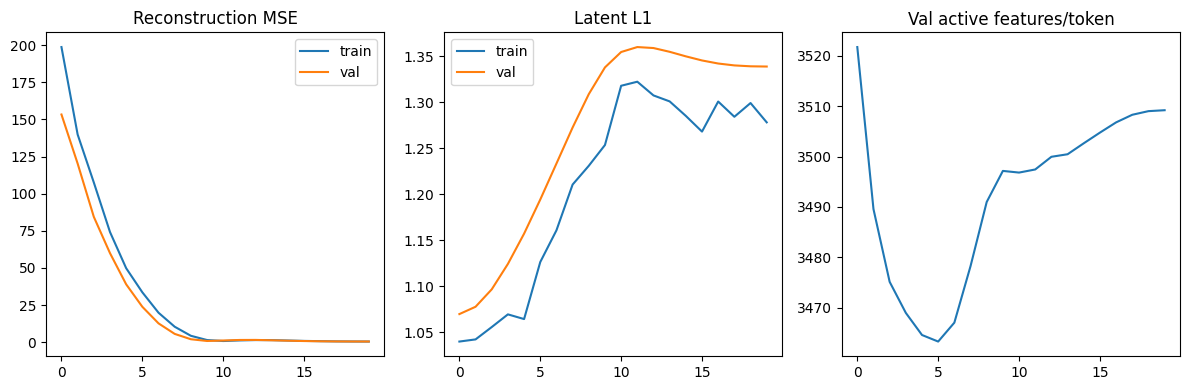

In [18]:
# ---- Curves ----
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(history["train_recon"], label="train")
plt.plot(history["val_recon"], label="val")
plt.title("Reconstruction MSE")
plt.legend()

plt.subplot(1,3,2)
plt.plot(history["train_l1"], label="train")
plt.plot(history["val_l1"], label="val")
plt.title("Latent L1")
plt.legend()

plt.subplot(1,3,3)
plt.plot(history["val_active"])
plt.title("Val active features/token")

plt.tight_layout()
plt.show()

In [19]:
# ---- Save checkpoint ----
ckpt = {
    "model_state": sae.state_dict(),
    "d_in": d_in,
    "d_latent": d_latent,
    "lambda_l1": lambda_l1,
    "history": history,
}
torch.save(ckpt, "sae_qwen_layer20.pt")
print("Saved: sae_qwen_layer20.pt")

Saved: sae_qwen_layer20.pt


In [20]:
# --- SAE Evaluation Section ---
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

# Optional (for latent-space scatter)
try:
    import umap
    HAS_UMAP = True
except Exception:
    HAS_UMAP = False

device = "cuda" if torch.cuda.is_available() else "cpu"
x_train = x_train.to(device)

# -------------------------
# 1) Adapt this wrapper to your SAE API
# -------------------------
def sae_forward(sae, x):
    """
    Returns:
      x_hat: [B, D] reconstruction
      z:     [B, K] latent activations (post-activation sparse codes)
    """
    out = sae(x)

    # common patterns
    if isinstance(out, tuple) and len(out) >= 2:
        x_hat, z = out[0], out[1]
    elif isinstance(out, dict):
        x_hat = out.get("x_hat", out.get("recon", out.get("reconstruction")))
        z = out.get("z", out.get("latents", out.get("codes")))
        if x_hat is None or z is None:
            raise ValueError("Dict output missing reconstruction/latent keys.")
    else:
        raise ValueError("Unknown SAE output format. Update sae_forward().")

    return x_hat, z

# -------------------------
# 2) Core metrics
# -------------------------
@torch.no_grad()
def evaluate_sae(sae, x, batch_size=4096, active_threshold=1e-6):
    sae.eval()
    n = x.shape[0]

    mse_sum = 0.0
    var_sum = 0.0
    l1_sum = 0.0
    active_sum = 0.0
    dead_counter = None
    usage_counter = None

    # We'll collect small sample for plots
    z_samples = []

    for i in range(0, n, batch_size):
        xb = x[i:i+batch_size]
        x_hat, z = sae_forward(sae, xb)

        # Reconstruction
        err = (xb - x_hat)
        mse_sum += (err.pow(2).mean(dim=1)).sum().item()
        var_sum += xb.var(dim=1, unbiased=False).sum().item()

        # Sparsity
        l1_sum += z.abs().mean(dim=1).sum().item()
        active = (z.abs() > active_threshold).float()
        active_sum += active.sum(dim=1).sum().item()

        # Feature usage/dead features
        fired = (active.sum(dim=0) > 0).float()   # per feature in this batch
        if dead_counter is None:
            dead_counter = torch.zeros_like(fired)
            usage_counter = torch.zeros_like(fired)

        dead_counter += (1.0 - fired)             # count batches where feature never fired
        usage_counter += active.sum(dim=0).detach().cpu()

        # keep sample for visualizations
        if len(z_samples) < 10:
            z_samples.append(z.detach().float().cpu())

    mse = mse_sum / n
    mean_var = var_sum / n
    explained_var = max(0.0, 1.0 - (mse / (mean_var + 1e-12)))

    avg_l1 = l1_sum / n
    avg_active_per_token = active_sum / n

    total_feature_activations = usage_counter.sum().item() + 1e-12
    p = (usage_counter / total_feature_activations).numpy()
    p_nonzero = p[p > 0]
    usage_entropy = float(-(p_nonzero * np.log(p_nonzero)).sum())
    usage_perplexity = float(np.exp(usage_entropy))  # "effective number of used features"

    dead_feature_rate = float((usage_counter == 0).float().mean().item())

    z_sample = torch.cat(z_samples, dim=0) if len(z_samples) else None

    return {
        "mse": mse,
        "explained_variance": explained_var,
        "avg_l1_latent": avg_l1,
        "avg_active_features_per_token": avg_active_per_token,
        "dead_feature_rate": dead_feature_rate,
        "usage_entropy": usage_entropy,
        "usage_perplexity": usage_perplexity,
        "usage_counter": usage_counter.numpy(),
        "z_sample": z_sample.numpy() if z_sample is not None else None,
    }

metrics = evaluate_sae(sae, x_train, batch_size=2048, active_threshold=1e-6)

print("=== SAE Metrics ===")
for k in [
    "mse",
    "explained_variance",
    "avg_l1_latent",
    "avg_active_features_per_token",
    "dead_feature_rate",
    "usage_entropy",
    "usage_perplexity",
]:
    print(f"{k:>32}: {metrics[k]:.6f}")

=== SAE Metrics ===
                             mse: 0.446340
              explained_variance: 0.997511
                   avg_l1_latent: 1.290660
   avg_active_features_per_token: 3499.733333
               dead_feature_rate: 0.097517
                   usage_entropy: 8.587152
                usage_perplexity: 5362.322600


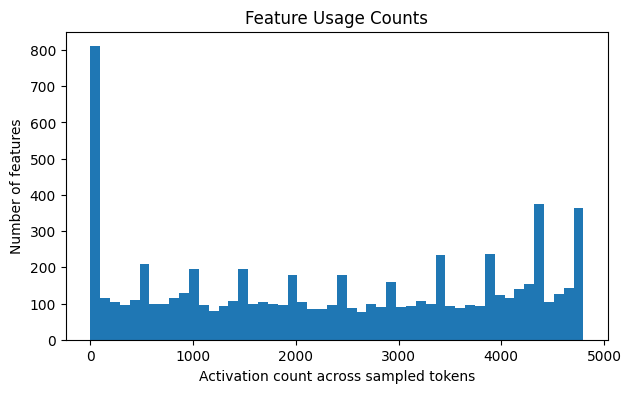

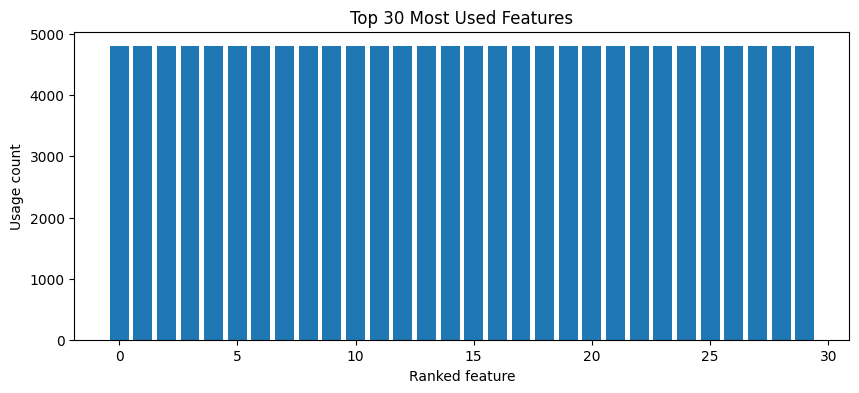

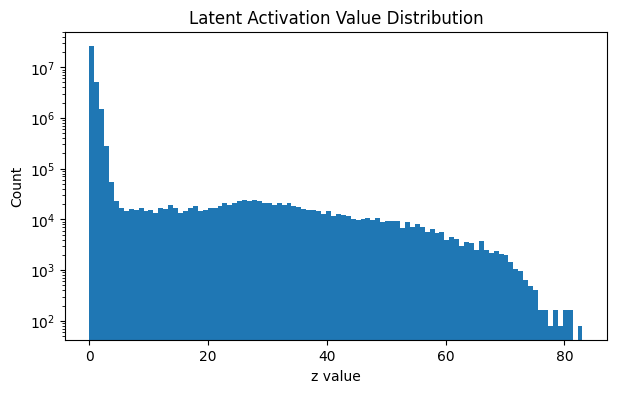

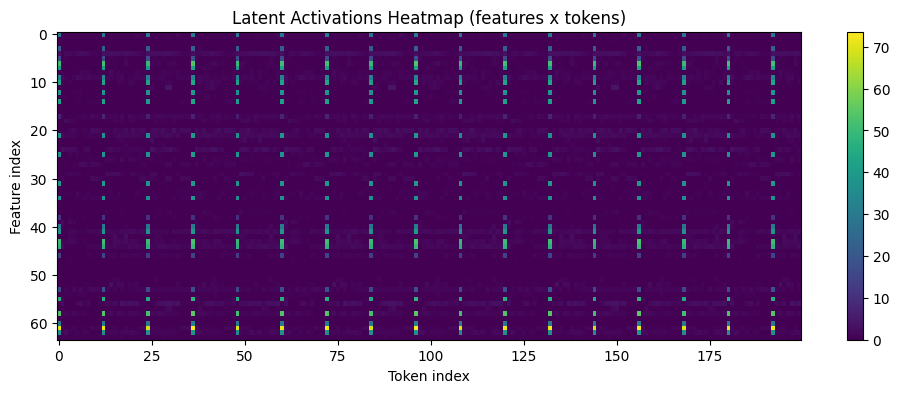

UMAP not installed. `pip install umap-learn` to enable latent-space plot.


In [21]:
# -------------------------
# 3) Visualizations
# -------------------------
usage = metrics["usage_counter"]
z_sample = metrics["z_sample"]

# Feature usage histogram
plt.figure(figsize=(7,4))
plt.hist(usage, bins=50)
plt.title("Feature Usage Counts")
plt.xlabel("Activation count across sampled tokens")
plt.ylabel("Number of features")
plt.show()

# Top most-used features
top_k = 30
top_idx = np.argsort(-usage)[:top_k]
plt.figure(figsize=(10,4))
plt.bar(np.arange(top_k), usage[top_idx])
plt.title(f"Top {top_k} Most Used Features")
plt.xlabel("Ranked feature")
plt.ylabel("Usage count")
plt.show()

if z_sample is not None:
    # Latent activation value distribution
    plt.figure(figsize=(7,4))
    plt.hist(z_sample.flatten(), bins=100)
    plt.title("Latent Activation Value Distribution")
    plt.xlabel("z value")
    plt.ylabel("Count")
    plt.yscale("log")
    plt.show()

    # Sequence-position heatmap-like view (first 200 tokens, first 64 features)
    n_tokens = min(200, z_sample.shape[0])
    n_feats = min(64, z_sample.shape[1])
    plt.figure(figsize=(12,4))
    plt.imshow(z_sample[:n_tokens, :n_feats].T, aspect="auto", interpolation="nearest")
    plt.title("Latent Activations Heatmap (features x tokens)")
    plt.xlabel("Token index")
    plt.ylabel("Feature index")
    plt.colorbar()
    plt.show()

    # Optional UMAP projection of token latents
    if HAS_UMAP and z_sample.shape[0] > 200:
        z_for_umap = z_sample[:5000]
        reducer = umap.UMAP(n_neighbors=30, min_dist=0.05, metric="cosine", random_state=42)
        z_2d = reducer.fit_transform(z_for_umap)

        plt.figure(figsize=(6,6))
        plt.scatter(z_2d[:,0], z_2d[:,1], s=2, alpha=0.5)
        plt.title("UMAP of SAE Latent Activations")
        plt.xlabel("UMAP-1")
        plt.ylabel("UMAP-2")
        plt.show()
    elif not HAS_UMAP:
        print("UMAP not installed. `pip install umap-learn` to enable latent-space plot.")

In [22]:
# -------------------------
# 4) Optional: quick baseline comparison helper
# -------------------------
def print_eval_table(rows):
    # rows: list of dicts with keys: name + metric keys
    cols = ["name","mse","explained_variance","avg_active_features_per_token","dead_feature_rate","usage_perplexity"]
    print(" | ".join(f"{c:>28}" for c in cols))
    print("-" * (31 * len(cols)))
    for r in rows:
        vals = []
        for c in cols:
            v = r[c]
            if isinstance(v, float):
                vals.append(f"{v:>28.6f}")
            else:
                vals.append(f"{str(v):>28}")
        print(" | ".join(vals))

# Example:
# rows = []
# for name, sae_model in [("sae_l1_1e-3", sae1), ("sae_l1_5e-4", sae2)]:
#     m = evaluate_sae(sae_model, x_train)
#     m["name"] = name
#     rows.append(m)
# print_eval_table(rows)